<a href="https://colab.research.google.com/github/safoura-banihashemi/predicting-online-news-popularity/blob/main/news_popularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Analytics and Text Mining (6 CFU)

- Project Title: Predicting Online News Popularity
- Professor: Prof. Stefano Lodi
- Author: Safoura Banihashemi
- Academic Year: 2024–2025

## Project Overview

This project focuses on predicting the Online News Popularity through three binary-classification methods using the PySpark library.

1. Logistic Regression
2. Random Forest
3. Gradient Boosted tree

## Dataset Description

The dataset consists of 39,644 articles published by Mashable over a period of two years. It includes a rich set of 61 features extracted from the articles, which can be grouped into:

- Text Features: Word counts, title/content length, and the rate of unique or non-stop words.

- Sentiment & Tonality: Polarity scores, subjectivity scores, and rates of positive vs. negative words (utilizing text mining metrics).

- Metadata & Context: Channel type (Lifestyle, Entertainment, Business, Social Media, Tech, World), publication day of the week, and the popularity of referenced keywords.

- Target Variable: The original dataset contains a continuous count of shares. For this project, this variable is engineered into two distinct classes to frame the task as a binary classification problem.

## Requirements

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pyspark
from pyspark.sql import SparkSession

# Spark Session
spark = (
    SparkSession.builder
    .appName("OnlineNewsPopularity")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark Version: {spark.version}")

Spark Version: 4.0.2


In [ ]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col as scol

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, UnivariateFeatureSelector
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics
from pyspark.sql import functions as F
import numpy as np

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

## Data Loading & Exploration

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("programmerrdai/online-news-popularity")
csv_file = os.path.join(path, "OnlineNewsPopularity.csv")
df = pd.read_csv(csv_file)
df.head()

100%|██████████| 7.33M/7.33M [00:00<00:00, 161MB/s]

Extracting files...


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [ ]:
print(f"Number of features = {df.shape[1]}")
print(f"Number of samples = {df.shape[0]}")

Number of features = 61
Number of samples = 39644


In [ ]:
# Feature list
print(f"Feature list: {df.columns}")

Feature list: Index(['url', ' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
      

In [ ]:
# Remove whitespace from column name
df.columns = df.columns.str.strip()

# Remove URL column
df.drop(columns=["url"], inplace=True)

# Target vector
y = df[["shares"]]

# Feature matrix
X = df.drop(columns=["shares"])

In [ ]:
# Print some samples
df.sample(5)

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
34472,89.0,10.0,355.0,0.595679,1.0,0.677686,65.0,5.0,30.0,1.0,...,0.10,0.5,-1.000000,-1.000000,-1.000000,1.000000,1.000000,0.500000,1.000000,4100
28039,191.0,11.0,176.0,0.767045,1.0,0.870968,9.0,6.0,1.0,0.0,...,0.05,0.4,-0.166667,-0.166667,-0.166667,0.000000,0.000000,0.500000,0.000000,1000
10933,523.0,11.0,402.0,0.651475,1.0,0.811715,4.0,2.0,0.0,21.0,...,0.10,1.0,-0.319325,-0.666667,-0.100000,0.000000,0.000000,0.500000,0.000000,1600
5971,622.0,8.0,96.0,0.659574,1.0,0.684211,3.0,3.0,0.0,1.0,...,0.10,0.5,-0.125000,-0.125000,-0.125000,0.454545,0.136364,0.045455,0.136364,1800
27541,199.0,10.0,229.0,0.488987,1.0,0.503106,2.0,1.0,14.0,1.0,...,0.10,0.5,-0.383333,-0.500000,-0.150000,0.400000,0.300000,0.100000,0.300000,94800


## Exploratory Data Analysis (EDA)

In [ ]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   timedelta                      39644 non-null  float64
 1   n_tokens_title                 39644 non-null  float64
 2   n_tokens_content               39644 non-null  float64
 3   n_unique_tokens                39644 non-null  float64
 4   n_non_stop_words               39644 non-null  float64
 5   n_non_stop_unique_tokens       39644 non-null  float64
 6   num_hrefs                      39644 non-null  float64
 7   num_self_hrefs                 39644 non-null  float64
 8   num_imgs                       39644 non-null  float64
 9   num_videos                     39644 non-null  float64
 10  average_token_length           39644 non-null  float64
 11  num_keywords                   39644 non-null  float64
 12  data_channel_is_lifestyle      39644 non-null 

In [ ]:
# Generate summary statistics for each feature
summary = df.describe(include="all").T
display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max
timedelta,39644.0,354.53,214.16,8.00,164.00,339.00,542.00,731.00
n_tokens_title,39644.0,10.40,2.11,2.00,9.00,10.00,12.00,23.00
n_tokens_content,39644.0,546.51,471.11,0.00,246.00,409.00,716.00,8474.00
n_unique_tokens,39644.0,0.55,3.52,0.00,0.47,0.54,0.61,701.00
n_non_stop_words,39644.0,1.00,5.23,0.00,1.00,1.00,1.00,1042.00
n_non_stop_unique_tokens,39644.0,0.69,3.26,0.00,0.63,0.69,0.75,650.00
num_hrefs,39644.0,10.88,11.33,0.00,4.00,8.00,14.00,304.00
num_self_hrefs,39644.0,3.29,3.86,0.00,1.00,3.00,4.00,116.00
num_imgs,39644.0,4.54,8.31,0.00,1.00,1.00,4.00,128.00
num_videos,39644.0,1.25,4.11,0.00,0.00,0.00,1.00,91.00


#### The "shares" distribution is heavily **right-skewed** and naturally **long-tailed**.

- The data has a heavy "long tail" where,

  $\text{Mode } (1,100) < \text{Median } (1,400) < \text{Mean } (3,395)$

  This shows that a typical article gets a modest number of shares, while a small percentage of articles go highly viral.

- Since the distribution is so skewed, predicting the exact number of shares is impractical. Transforming it into a binary classification problem simplifies the task into predicting Popular vs. Unpopular.

- Considering Median as threshold (1,400 shares), create almost balanced dataset (50.66% Unpopular, 49.34% Popular).

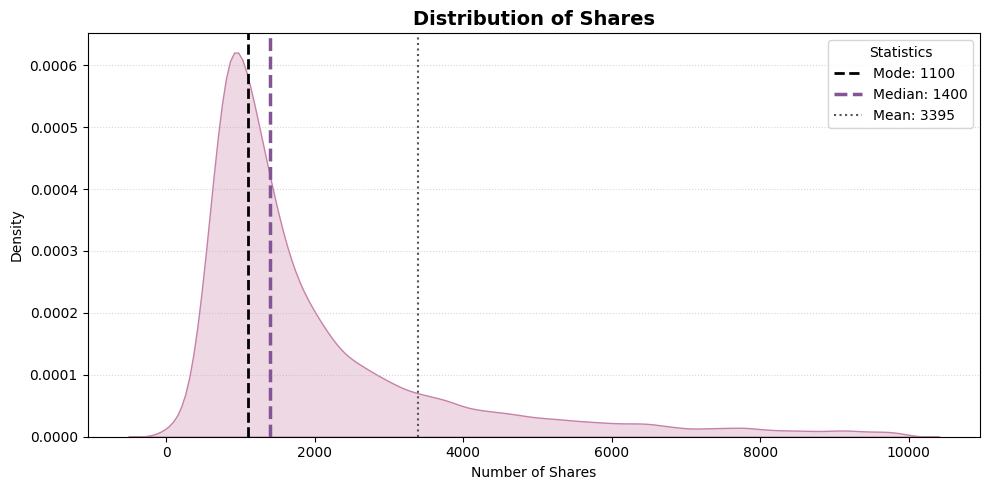

In [ ]:
# Shares distribution

# Filter out for better presentation
filtered_y = y[y['shares'] < 10_000]['shares'].copy()

# Compute mean, median and mode
mean_val   = y['shares'].mean()
median_val = y['shares'].median()
mode_val   = y['shares'].mode()[0]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(filtered_y, color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)
ax.axvline(mode_val, color='black', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.0f}')
ax.axvline(median_val, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.0f}')
ax.axvline(mean_val, color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.0f}')
ax.set_title("Distribution of Shares", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Shares"); ax.set_ylabel("Density")
ax.set_facecolor('white'); ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(title="Statistics")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the median of the target variable
THRESHOLD = int(df['shares'].median())
print(f"Median shares: {THRESHOLD}")

# Convert the target into a binary classification label
df["label"] = (df["shares"] > THRESHOLD).astype(int)
df.drop(columns=["shares"], inplace=True)

counts = df["label"].value_counts()
total  = len(df)
print(f"\nClass distribution:")
print(f"Popular(1): {counts.get(1,0)} ({counts.get(1,0)/total:.2%})")
print(f"Unpopular(0): {counts.get(0,0)} ({counts.get(0,0)/total:.2%})")

Median shares: 1400

Class distribution:
Popular(1): 19562 (49.34%)
Unpopular(0): 20082 (50.66%)


In [ ]:
# Print some samples
df.sample(5)

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,label
13346,475.0,11.0,912.0,0.461883,1.0,0.634234,33.0,4.0,11.0,0.0,...,0.033333,1.00,-0.320000,-0.400000,-0.100,0.312500,0.250000,0.187500,0.250000,0
6455,612.0,8.0,248.0,0.641129,1.0,0.794872,5.0,3.0,1.0,0.0,...,0.166667,0.90,-0.208333,-0.291667,-0.125,0.571429,0.357143,0.071429,0.357143,0
14633,449.0,11.0,482.0,0.541578,1.0,0.713287,4.0,2.0,1.0,0.0,...,0.100000,0.85,-0.309838,-0.600000,-0.100,0.454545,0.136364,0.045455,0.136364,0
16883,402.0,12.0,317.0,0.587859,1.0,0.778409,5.0,3.0,1.0,0.0,...,0.033333,1.00,0.000000,0.000000,0.000,0.333333,0.250000,0.166667,0.250000,1
9265,555.0,12.0,441.0,0.566820,1.0,0.662021,8.0,5.0,1.0,0.0,...,0.033333,0.60,-0.168750,-0.300000,-0.050,0.066667,0.033333,0.433333,0.033333,0


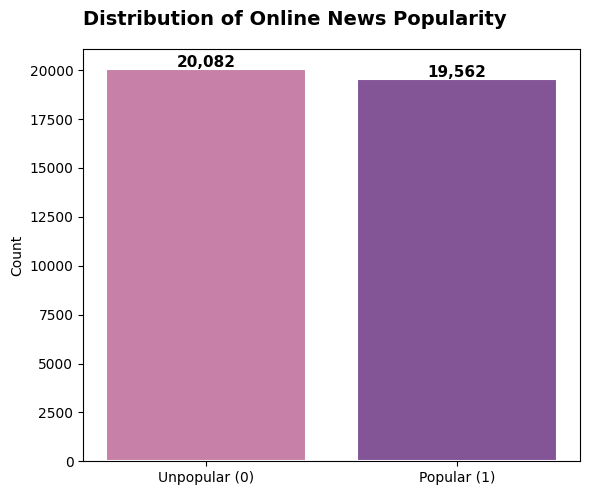

In [ ]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Distribution of Online News Popularity", fontsize=14, fontweight="bold")
counts_plot = df["label"].value_counts().sort_index()
bars = ax.bar(["Unpopular (0)", "Popular (1)"], counts_plot.values, color=["#C781A8", "#835496"], edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, counts_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Pearson correlation heatmap (top 20 features)

### Pearson Correlation (r)

Pearson Correlation is a way to calculate the pairwise correlation between a single target (label) and a set of other variables.

Mathematically, it measures the linear relationship between two variables, $X$ (feature) and $Y$ (label), using this formula:

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}$$

- Numerator (Covariance): It checks if $X$ and $Y$ move together. If $X$ is above its mean when $Y$ is also above its mean, the correlation goes up.

- Denominator (Normalization): It divides by the product of the standard deviations. This "squashes" the result into a range between -1.0 and +1.0.

- The results:

  - +1.0: Perfect positive linear relationship.

  - 1.0: Perfect negative linear relationship.

  - 0: No linear relationship at all.

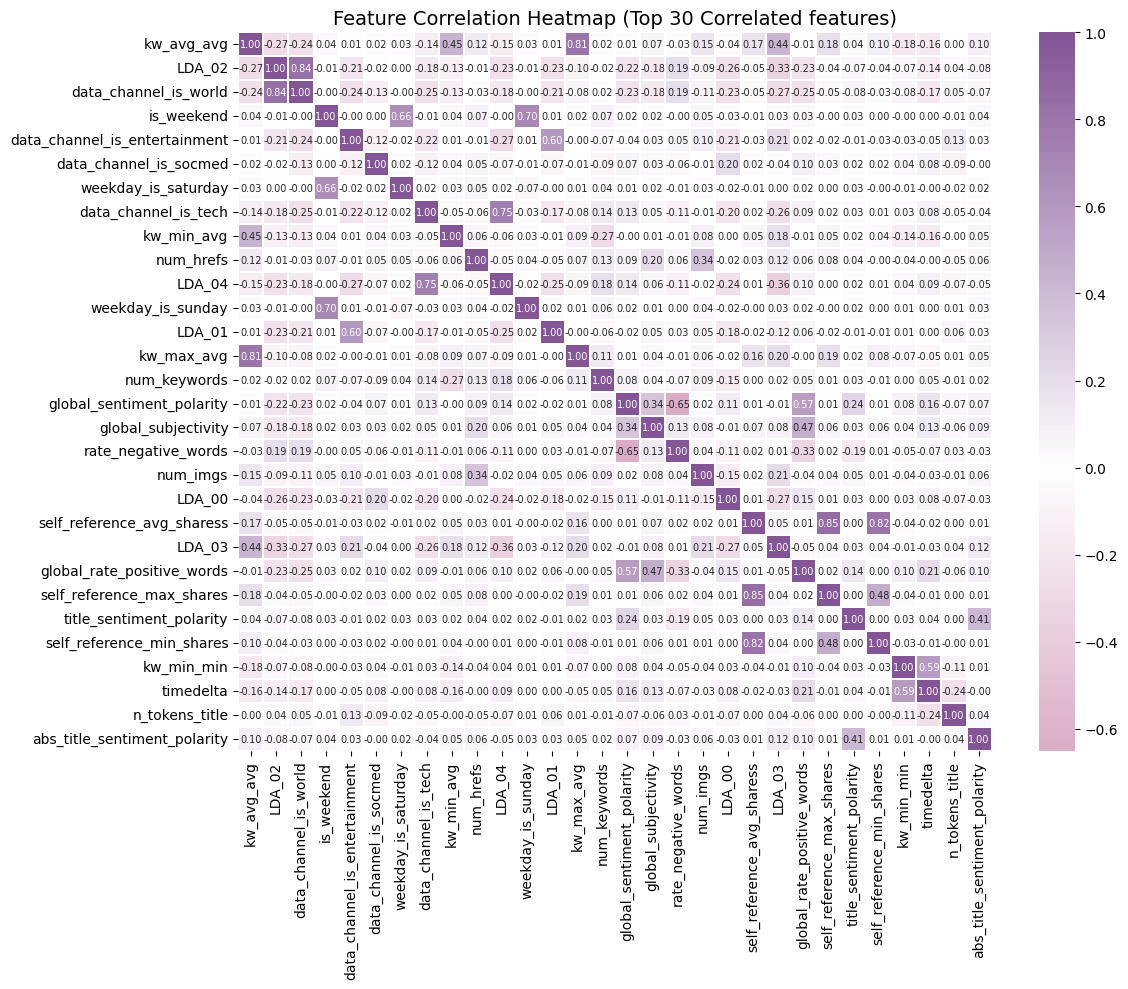

In [ ]:
feature_list = [c for c in X.columns]
label_corr = df[feature_list].corrwith(df["label"]).abs().nlargest(30)
top20_features = label_corr.index.tolist()

colors_cmap = ["#C781A8", "#FFFFFF", "#835496"]
cmap = LinearSegmentedColormap.from_list("custom", colors_cmap)

plt.figure(figsize=(12, 10))
sub_corr = df[top20_features].corr()
sns.heatmap(sub_corr, cmap=cmap, center=0, linewidths=0.3,
            annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap (Top 30 Correlated features)", fontsize=14)
plt.tight_layout()
plt.show()

#### Feature Relationships (Multicollinearity) and Non-Linearity

The correlation between the features and the shares column are very close to 0, shows that there is no simple "straight line" relationship between any single feature and how viral an article gets. It justifies using non-linear models like **Random Forest** and **Gradient Boosted Trees**.

### Relative mean difference between popular vs unpopular articles

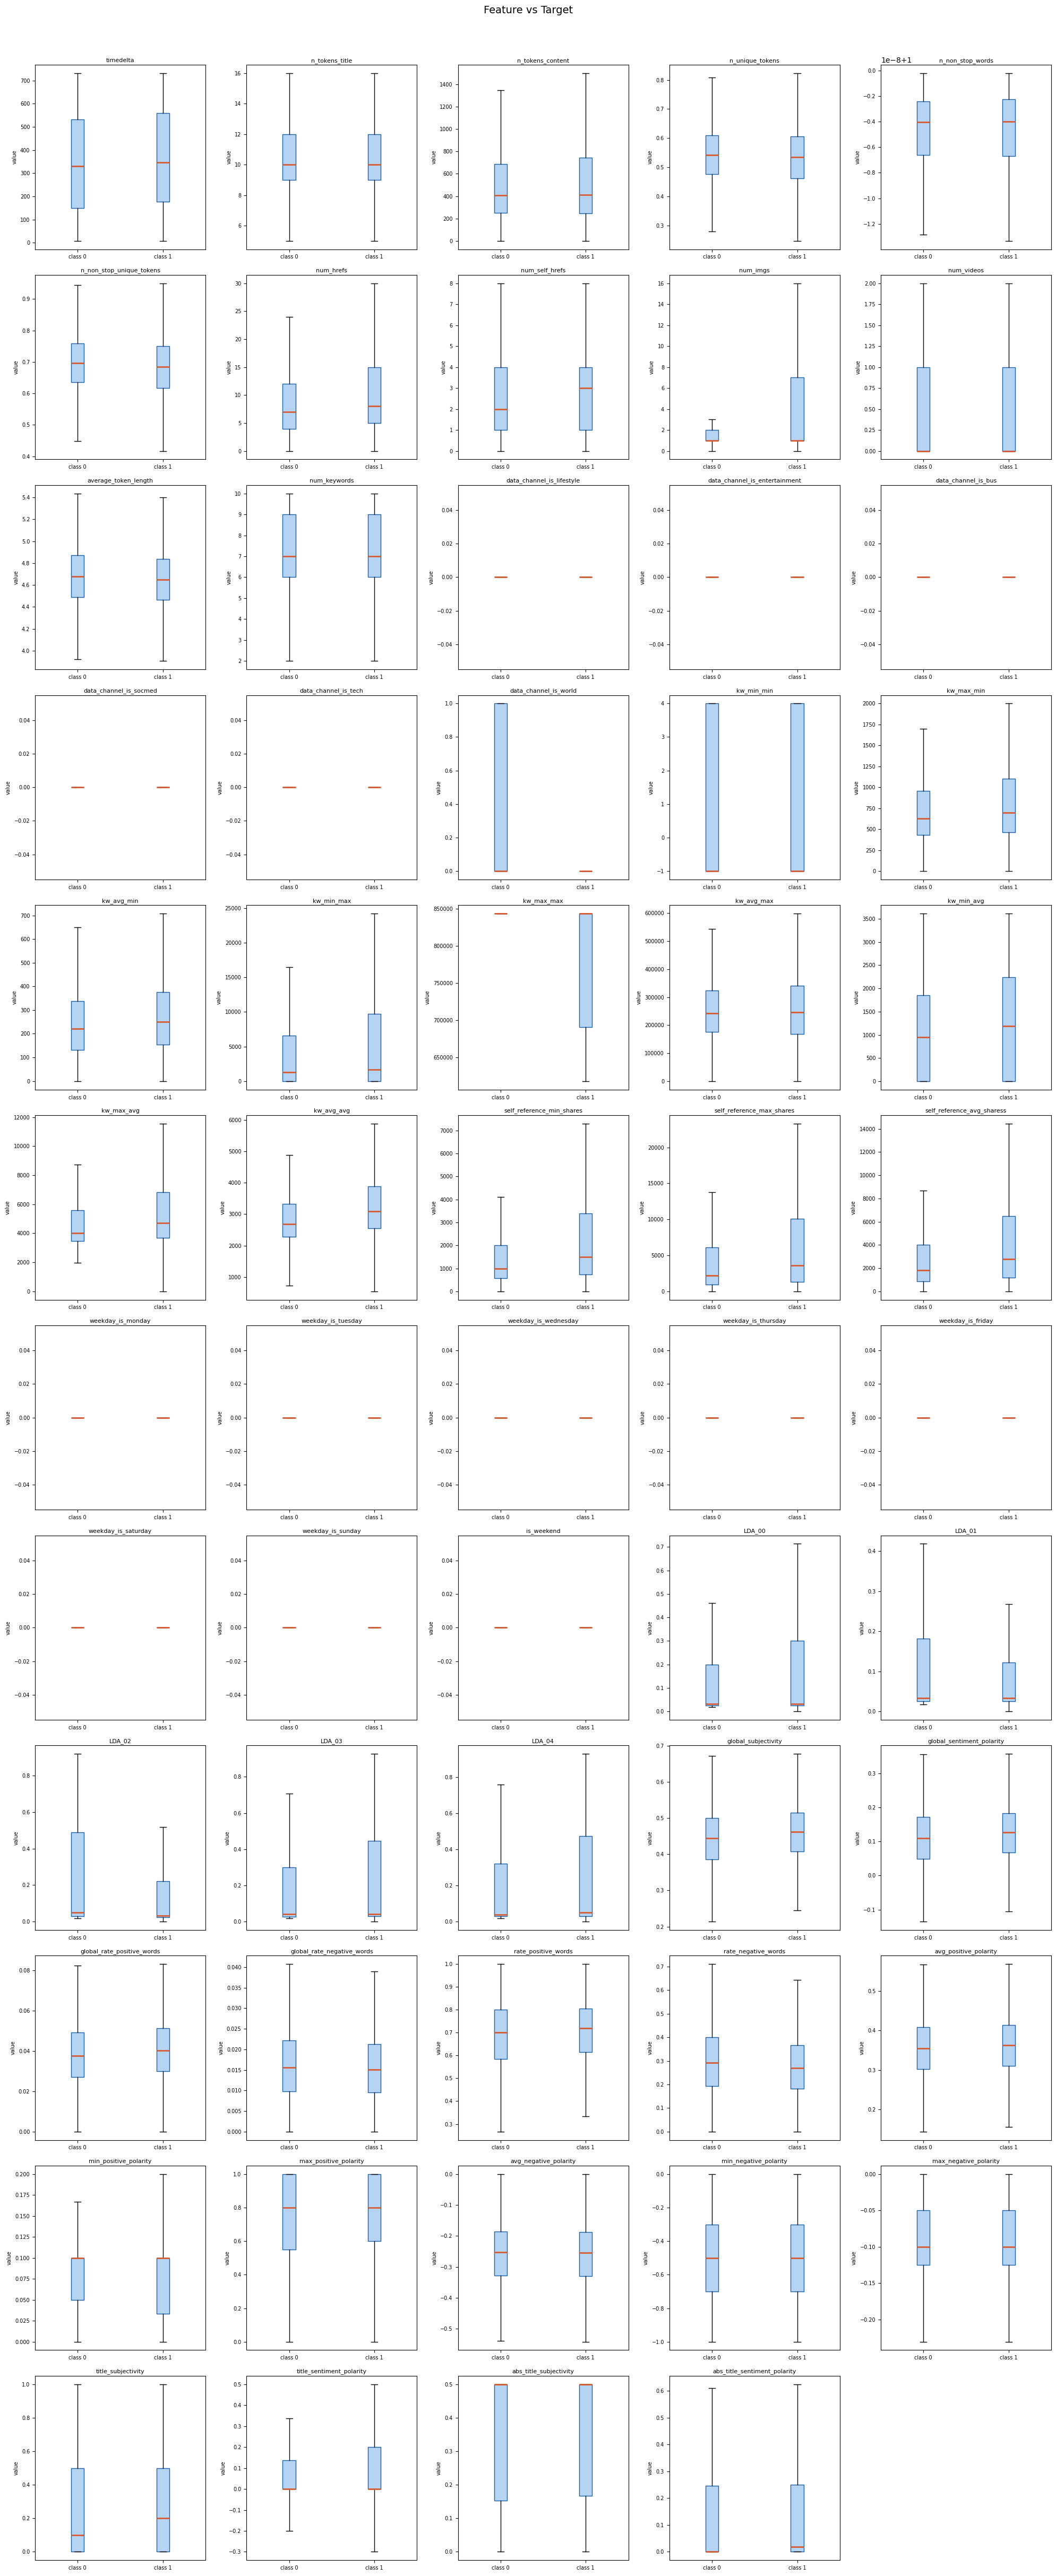

In [ ]:
# Build the figure
n = len(feature_list)
ncols = 5                          # how many plots per row
nrows = (n + ncols - 1) // ncols  # auto-calculate rows needed

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()              # easier to loop over

# Draw one box plot per feature
for i, feat in enumerate(feature_list):
    ax = axes[i]

    groups = [df[df["label"] == val][feat].dropna()
              for val in sorted(df["label"].unique())]

    ax.boxplot(groups,
               tick_labels=[f"class {v}" for v in sorted(df["label"].unique())],
               showfliers=False,   # hide extreme outliers for readability
               patch_artist=True,
               boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
               medianprops=dict(color="#D85A30", linewidth=2))

    ax.set_title(feat, fontsize=8, pad=4)
    ax.set_ylabel("value", fontsize=7)
    ax.tick_params(labelsize=7)

# Hide any unused subplot slots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature vs Target",fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

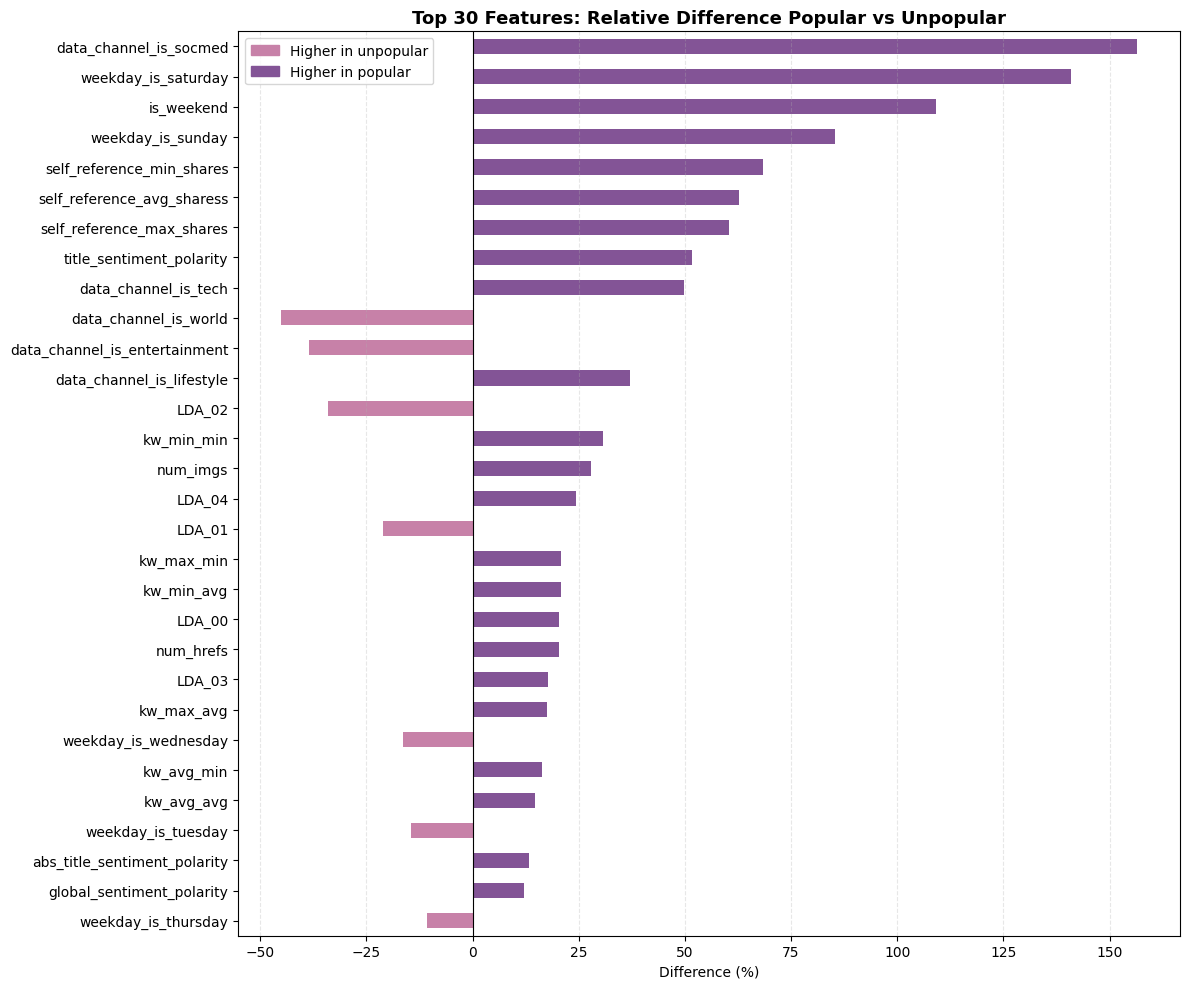

In [ ]:
unpopular_mean = df[df['label'] == 0].mean(numeric_only=True)
popular_mean   = df[df['label'] == 1].mean(numeric_only=True)

class_diff = pd.DataFrame({'Mean_Unpopular': unpopular_mean,
                            'Mean_Popular':   popular_mean})
class_diff['Diff (%)'] = (
    (class_diff['Mean_Popular'] - class_diff['Mean_Unpopular'])
    / class_diff['Mean_Unpopular'].replace(0, np.nan)
) * 100
class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()
class_diff = class_diff.drop('label', errors='ignore')

top30_diff  = class_diff.sort_values('Abs_Diff', ascending=False).head(30)
colors_diff = np.where(top30_diff['Diff (%)'] > 0, '#835496', '#C781A8')

plt.figure(figsize=(12, 10))
top30_diff['Diff (%)'].plot(kind='barh', color=colors_diff)
plt.title('Top 30 Features: Relative Difference Popular vs Unpopular',
          fontsize=13, fontweight='bold')
plt.xlabel('Difference (%)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis()
purple_patch = mpatches.Patch(color='#C781A8', label='Higher in unpopular')
pink_patch = mpatches.Patch(color='#835496', label='Higher in popular')
plt.legend(handles=[purple_patch, pink_patch])
plt.tight_layout()
plt.show()

In [ ]:
# Push to Spark
sdf = spark.createDataFrame(df)
sdf.printSchema()
print(f"Total rows in Spark df: {sdf.count()}")

root
 |-- timedelta: double (nullable = true)
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: double (nullable = true)
 |-- kw_max_min: double (nullable = true)
 |-- kw_avg_min: double (nullabl

The pandas DataFrame `df` (after cleaning and feature engineering) is converted into a PySpark DataFrame `sdf` using `spark.createDataFrame(df)`.

In [ ]:
# Convert the pandas DataFrame 'df' to a Spark DataFrame 'sdf'
sdf = spark.createDataFrame(df)

# Print the schema and total rows to verify the Spark DataFrame
sdf.printSchema()
print(f"Total rows in Spark df: {sdf.count()}")

## Feature Engineering

### Why this matters
Raw features fed into the original model had two problems:
1. **Skewed distributions**: features like `n_tokens_content`, `self_reference_avg_shares`, and keyword
   counts span several orders of magnitude. Log-transforming them compresses the tail, stabilises
   variance, and is especially important for Logistic Regression which assumes roughly Gaussian inputs.
2. **Missing interaction signals**: the ratio of links to content length, or the combined keyword
   strength, are meaningful signals that neither feature alone captures. We add 6 engineered features.

## Rolling-Window Time-Series Split

Unlike a standard cross-validation where data is shuffled randomly, this method respects the temporal order.

In [ ]:
# Order dataset => Sort oldest (larger value) → newest (smaller value)

sdf_ordered = (sdf.orderBy(scol("timedelta").desc()).withColumn("row_num", row_number().over(Window.orderBy(scol("timedelta").desc())) - 1))

sdf_ordered.cache()
total_rows = sdf_ordered.count()


# ==========================================================
# 2. WINDOW PARAMETERS
# ==========================================================

L = 3_000          # test size / step size
num_folds = 6

INITIAL_TRAIN_SIZE = 15_150
TRAIN_FRAC = 0.70

splits = []

print("\nWindow parameters:")
print(f"Initial train size : {INITIAL_TRAIN_SIZE:,}")
print(f"Step size (L)      : {L:,}")
print(f"Number of folds    : {num_folds}")

print(f"\n{'─'*95}")
print(f"  {'Fold':>4}  {'Train start':>11}  {'Train end':>9}  "
      f"{'Eval start':>10}  {'Eval end':>8}  "
      f"{'Test start':>10}  {'Test end':>8}  "
      f"{'n_train':>8}  {'n_eval':>7}  {'n_test':>7}")
print(f"{'─'*95}")

# ==========================================================
# 3. EXPANDING WINDOW
# ==========================================================

for i in range(num_folds):

    # -------------------------
    # Expanding train window
    # -------------------------
    train_end = INITIAL_TRAIN_SIZE + (i * L) - 1

    W = train_end + 1

    train_size = int(W * TRAIN_FRAC)
    eval_size = W - train_size

    # -------------------------
    # Train: [0 → train_size)
    # -------------------------
    tr_start = 0
    tr_end = train_size - 1

    # -------------------------
    # Eval: [train_size → W)
    # -------------------------
    ev_start = train_size
    ev_end = W - 1

    # -------------------------
    # Future test block
    # -------------------------
    te_start = W
    te_end = min(W + L - 1, total_rows - 1)

    # Boundary protection
    if te_start >= total_rows:
        break

    # -------------------------
    # Filter splits
    # -------------------------
    train_fold = sdf_ordered.filter(
        (scol("row_num") >= tr_start) &
        (scol("row_num") <= tr_end)
    )

    eval_fold = sdf_ordered.filter(
        (scol("row_num") >= ev_start) &
        (scol("row_num") <= ev_end)
    )

    test_fold = sdf_ordered.filter(
        (scol("row_num") >= te_start) &
        (scol("row_num") <= te_end)
    )

    splits.append((train_fold, eval_fold, test_fold))

    # Verification
    n_train = train_fold.count()
    n_eval = eval_fold.count()
    n_test = test_fold.count()

    print(f"  {i+1:>4}  {tr_start:>11,}  {tr_end:>9,}  "
          f"{ev_start:>10,}  {ev_end:>8,}  "
          f"{te_start:>10,}  {te_end:>8,}  "
          f"{n_train:>8,}  {n_eval:>7,}  {n_test:>7}")

print(f"{'─'*95}")
print(f"\nTotal folds created: {len(splits)}")


Window parameters:
Initial train size : 15,150
Step size (L)      : 3,000
Number of folds    : 6

───────────────────────────────────────────────────────────────────────────────────────────────
  Fold  Train start  Train end  Eval start  Eval end  Test start  Test end   n_train   n_eval   n_test
───────────────────────────────────────────────────────────────────────────────────────────────
     1            0     10,604      10,605    15,149      15,150    18,149    10,605    4,545     3000
     2            0     12,704      12,705    18,149      18,150    21,149    12,705    5,445     3000
     3            0     14,803      14,804    21,149      21,150    24,149    14,804    6,346     3000
     4            0     16,904      16,905    24,149      24,150    27,149    16,905    7,245     3000
     5            0     19,004      19,005    27,149      27,150    30,149    19,005    8,145     3000
     6            0     21,104      21,105    30,149      30,150    33,149    21,105    9,0

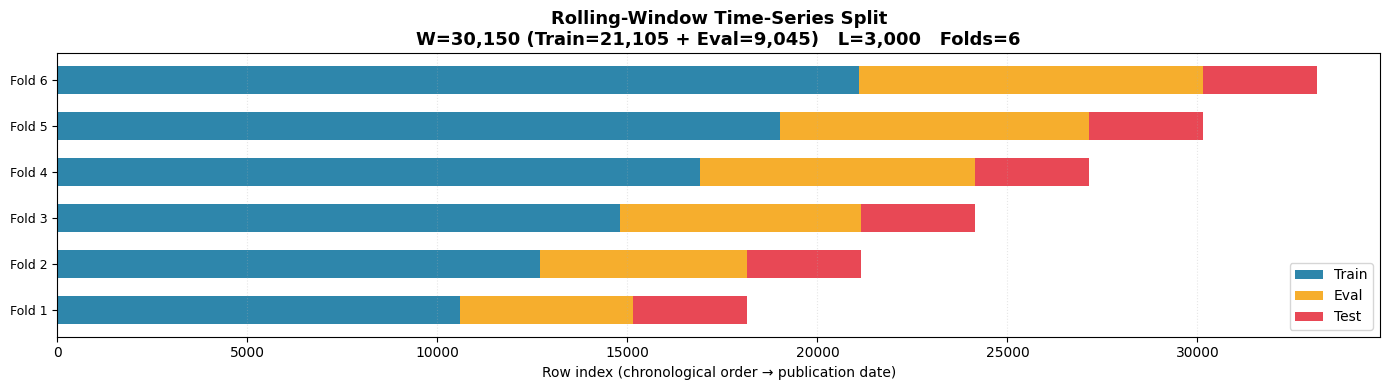

In [ ]:
# Visualise the splits
N_SPLITS = len(splits)
TRAIN_SIZE = int(W * TRAIN_FRAC)
EVAL_SIZE = W - TRAIN_SIZE
fig, ax = plt.subplots(figsize=(14, max(4, N_SPLITS * 0.6)))

for i, (tr, ev, te) in enumerate(splits):
    tr_s = tr.agg(F.min("row_num")).collect()[0][0]
    tr_e = tr.agg(F.max("row_num")).collect()[0][0]
    ev_s = ev.agg(F.min("row_num")).collect()[0][0]
    ev_e = ev.agg(F.max("row_num")).collect()[0][0]
    te_s = te.agg(F.min("row_num")).collect()[0][0]
    te_e = te.agg(F.max("row_num")).collect()[0][0]

    ax.barh(i, tr_e - tr_s, left=tr_s, height=0.6,
            color="#2E86AB", label="Train"  if i == 0 else "")
    ax.barh(i, ev_e - ev_s, left=ev_s, height=0.6,
            color="#F6AE2D", label="Eval"   if i == 0 else "")
    ax.barh(i, te_e - te_s, left=te_s, height=0.6,
            color="#E84855", label="Test"   if i == 0 else "")

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)], fontsize=9)
ax.set_xlabel("Row index (chronological order → publication date)")
ax.set_title(
    f"Rolling-Window Time-Series Split\n"
    f"W={W:,} (Train={TRAIN_SIZE:,} + Eval={EVAL_SIZE:,})   "
    f"L={L:,}   Folds={N_SPLITS}",
    fontsize=13, fontweight='bold'
)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### ANOVA (Analysis of Variance) Feature Selection

35% sample is enough to get stable AUC estimates while keeping sweep fast.

Split computed ONCE so every k candidate sees the exact same train/val data —
without this, AUC differences between k values could reflect split randomness rather than feature quality.

In [ ]:
# FEATURE COLUMNS
# Remove non-feature columns safely

excluded_cols = {"label", "timedelta", "row_num"}

feature_cols = [
    c for c in sdf.columns
    if c not in excluded_cols
]

print(f"Total candidate features: {len(feature_cols)}")


# ==========================================================
# 2. TEMPORAL SPLIT
# ==========================================================
# Use first expanding-window fold
# (past → future)

train_s, val_s, _ = splits[0]

print(
    f"\nTemporal sweep split:"
    f"\nTrain: {train_s.count():,}"
    f"\nValidation: {val_s.count():,}"
)


# ==========================================================
# 3. PREPROCESSING
# ==========================================================

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)


# ==========================================================
# 4. SWEEP CONFIG
# ==========================================================

k_candidates = [10, 20, 30, 40, 50, len(feature_cols)]

auc_scores = {}

best_k = None
best_auc = -1


evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)


print("\nANOVA feature selection sweep")
print("(Temporal split + Logistic Regression + AUC)\n")

print(
    f"{'k':>6}"
    f"{'AUC':>12}"
    f"{'Δ AUC':>12}"
    f"{'Selected?':>14}"
)

print("-" * 46)

prev_auc = None


# ==========================================================
# 5. FEATURE SELECTION SWEEP
# ==========================================================

for k in k_candidates:

    # ------------------------------------------
    # ANOVA selector
    # ------------------------------------------
    selector = (
        UnivariateFeatureSelector(
            featuresCol="scaled_features",
            outputCol="selected_features",
            labelCol="label",
            selectionMode="numTopFeatures"
        )
        .setFeatureType("continuous")
        .setLabelType("categorical")
        .setSelectionThreshold(k)
    )

    # ------------------------------------------
    # Logistic Regression
    # ------------------------------------------
    lr = LogisticRegression(
        featuresCol="selected_features",
        labelCol="label",
        maxIter=100,
        regParam=0.01,
        elasticNetParam=0.0,
        standardization=True,
        tol=1e-6
    )

    # ------------------------------------------
    # Pipeline
    # ------------------------------------------
    pipeline = Pipeline(
        stages=[
            assembler,
            scaler,
            selector,
            lr
        ]
    )

    # ------------------------------------------
    # Fit on TRAIN ONLY
    # ------------------------------------------
    model = pipeline.fit(train_s)

    # ------------------------------------------
    # Evaluate on FUTURE validation
    # ------------------------------------------
    preds = model.transform(val_s)

    auc = evaluator_auc.evaluate(preds)

    auc_scores[k] = auc

    # improvement over previous k
    delta = (
        f"{auc - prev_auc:+.4f}"
        if prev_auc is not None
        else "baseline"
    )

    # meaningful improvement threshold
    improvement_margin = 0.001

    is_best = auc > (best_auc + improvement_margin)

    selected = "YES" if is_best else "NO"

    print(
        f"{k:>6}"
        f"{auc:>12.4f}"
        f"{delta:>12}"
        f"{selected:>14}"
    )

    if is_best:
        best_auc = auc
        best_k = k

    prev_auc = auc


# ==========================================================
# 6. PLATEAU CHECK
# ==========================================================

best_idx = k_candidates.index(best_k)

recommended_k = best_k

for k in k_candidates:
    if (
        best_auc - auc_scores[k]
    ) <= 0.001:
        recommended_k = k
        break


print("\n" + "=" * 55)
print(f"Best k (highest AUC): {best_k}")
print(f"Best AUC            : {best_auc:.4f}")
print(f"Recommended k       : {recommended_k}")
print("=" * 55)


if recommended_k != best_k:
    print(
        "\nPerformance plateau detected."
        f"\nUsing k={recommended_k} is recommended "
        "for better interpretability with "
        "negligible AUC loss."
    )

Sweep sample — train: 11,228   val: 2,693

ANOVA feature selection sweep (UnivariateFeatureSelector + LR AUC):

     k       AUC  improvement   Selected?
  ----  --------  ----------  ----------
  10  0.6995      baseline  YES
  20  0.7023       +0.0028  YES
  30  0.7141       +0.0118  YES
  40  0.7130       -0.0011  NO
  50  0.7139       +0.0009  NO
  58  0.7148       +0.0009  YES

Best k = 58 (AUC = 0.7148)


In [ ]:
# Class balance check per fold
print("\nClass balance per fold (test set):")
print(f"  {'Fold':>4}  {'Class 0':>8}  {'Class 1':>8}  {'% Popular':>10}  {'Balanced?':>10}")
print(f"  {'-'*4}  {'-'*8}  {'-'*8}  {'-'*10}  {'-'*10}")

for i, (_, _, te) in enumerate(splits):
    counts   = te.groupBy("label").count().collect()
    count_0  = next((r["count"] for r in counts if r["label"] == 0), 0)
    count_1  = next((r["count"] for r in counts if r["label"] == 1), 0)
    pct_pop  = count_1 / (count_0 + count_1) * 100
    balanced = "✔" if 40 <= pct_pop <= 60 else "skewed"
    print(f"  {i+1:>4}  {count_0:>8,}  {count_1:>8,}  {pct_pop:>9.1f}%  {balanced:>10}")


Class balance per fold (test set):
  Fold   Class 0   Class 1   % Popular   Balanced?
  ----  --------  --------  ----------  ----------
     1     1,472     1,528       50.9%           ✔
     2     1,447     1,553       51.8%           ✔
     3     1,357     1,643       54.8%           ✔
     4     1,421     1,579       52.6%           ✔
     5     1,515     1,485       49.5%           ✔
     6     1,617     1,383       46.1%           ✔


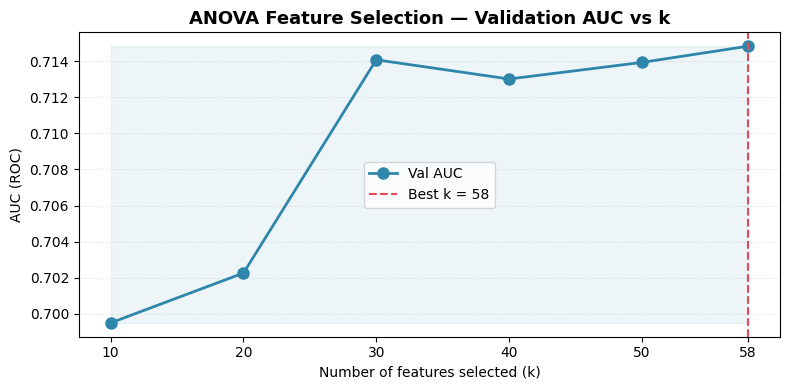

In [ ]:
# Plot AUC vs k
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(list(auc_scores.keys()), list(auc_scores.values()), marker="o", color="#2E86AB", linewidth=2, markersize=8, label="Val AUC")

# Shade the region between min and max AUC to show how flat the curve is
auc_vals = list(auc_scores.values())
ax.fill_between(list(auc_scores.keys()), min(auc_vals), max(auc_vals), alpha=0.08, color="#2E86AB")

# Mark the best k with a vertical line and annotation
ax.axvline(best_k, color="#E84855", linestyle="--", linewidth=1.5, label=f"Best k = {best_k}")

ax.set_title("ANOVA Feature Selection — Validation AUC vs k", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of features selected (k)")
ax.set_ylabel("AUC (ROC)")
ax.set_xticks(k_candidates)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Final selector for all training pipelines
selector_final = UnivariateFeatureSelector(
    featuresCol="scaled_features",
    outputCol="features",
    labelCol="label",
    selectionMode="numTopFeatures"
).setFeatureType("continuous") \
 .setLabelType("categorical")  \
 .setSelectionThreshold(best_k)

## Model Definitions & Grid Search

In [ ]:
from pyspark.ml.classification import (
    RandomForestClassifier,
    GBTClassifier,
    LogisticRegression
)
from pyspark.ml.tuning import ParamGridBuilder


# ==================================================
# Logistic Regression
# ==================================================
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    standardization=True,
    tol=1e-6
)

lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.001, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build()
)


# ==================================================
# Random Forest
# ==================================================
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [100, 200])
    .addGrid(rf.maxDepth, [5, 10, 15])
    .addGrid(rf.minInstancesPerNode, [1, 5])
    .build()
)


# ==================================================
# Gradient Boosted Tree
# ==================================================
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.stepSize, [0.03, 0.05, 0.1])
    .addGrid(gbt.maxIter, [50, 100])
    .build()
)


model_configs = [
    ("Logistic Regression", lr, lr_grid),
    ("Random Forest", rf, rf_grid),
    ("Gradient Boosted Tree", gbt, gbt_grid),
]

print("Model configs ready.")
for name, _, grid in model_configs:
    print(f"{name}: {len(grid)} configs")

Model configs ready.
Logistic Regression: 6 configs
Random Forest: 12 configs
Gradient Boosted Tree: 12 configs


## Helper Functions

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql import functions as F


# ==========================================================
# HELPER 1: Compute Metrics
# ==========================================================
def compute_metrics(predictions):
    """
    Compute evaluation metrics from Spark predictions DataFrame.

    Uses default Spark threshold (0.5).

    Returns:
        dict with accuracy, f1, precision, recall, auc
    """

    # AUC (threshold independent)
    auc_eval = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    auc = auc_eval.evaluate(predictions)

    # Metrics requiring hard labels
    preds_rdd = (
        predictions
        .select("prediction", "label")
        .rdd
        .map(lambda r: (float(r.prediction), float(r.label)))
    )

    metrics = MulticlassMetrics(preds_rdd)

    return {
        "accuracy": metrics.accuracy,
        "f1": metrics.fMeasure(1.0),
        "precision": metrics.precision(1.0),
        "recall": metrics.recall(1.0),
        "auc": auc
    }


# ==========================================================
# HELPER 2: Train + Evaluate One Model
# ==========================================================
def train_and_evaluate(
    name,
    estimator,
    param_grid,
    train_sdf,
    eval_sdf,
    test_sdf,
    pre_stages
):
    """
    Workflow:
      1. Hyperparameter tuning on TRAIN only
      2. Best model refit on TRAIN + EVAL
      3. Final evaluation on TEST

    Returns:
        metrics, final_model
    """

    evaluator_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    pipeline = Pipeline(
        stages=pre_stages + [estimator]
    )

    # --------------------------------------------------
    # STEP 1: Hyperparameter tuning
    # --------------------------------------------------
    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator_auc,
        numFolds=3,
        parallelism=2,
        seed=42
    )

    print(f"\n[{name}] Hyperparameter tuning...", end=" ", flush=True)

    cv_model = cv.fit(train_sdf)

    print("done.")

    # --------------------------------------------------
    # STEP 2: Refit best model on TRAIN + EVAL
    # --------------------------------------------------
    full_train = train_sdf.union(eval_sdf)

    best_pipeline = cv_model.bestModel

    final_model = best_pipeline.copy({})

    # retrain using full historical window
    final_model = final_model.fit(full_train)

    # --------------------------------------------------
    # STEP 3: Final test evaluation
    # --------------------------------------------------
    test_preds = final_model.transform(test_sdf)

    metrics = compute_metrics(test_preds)

    print(
        f"[{name}] "
        f"ACC={metrics['accuracy']:.4f} | "
        f"F1={metrics['f1']:.4f} | "
        f"P={metrics['precision']:.4f} | "
        f"R={metrics['recall']:.4f} | "
        f"AUC={metrics['auc']:.4f}"
    )

    return metrics, final_model

In [ ]:
def run_rolling_window(
    model_configs,
    splits,
    pre_stages
):
    """
    Run all models across all temporal folds.
    """

    all_results = {
        name: [] for name, _, _ in model_configs
    }

    for fold_idx, (train_sdf, eval_sdf, test_sdf) in enumerate(splits):

        print(f"\n{'═'*70}")
        print(f"FOLD {fold_idx+1}/{len(splits)}")
        print(f"{'═'*70}")

        # Cache fold data
        train_sdf.cache()
        eval_sdf.cache()
        test_sdf.cache()

        for name, estimator, param_grid in model_configs:

            print(f"\n── {name} ──")

            try:

                metrics, _ = train_and_evaluate(
                    name=name,
                    estimator=estimator,
                    param_grid=param_grid,
                    train_sdf=train_sdf,
                    eval_sdf=eval_sdf,
                    test_sdf=test_sdf,
                    pre_stages=pre_stages
                )

                metrics["fold"] = fold_idx + 1

                all_results[name].append(metrics)

            except Exception as e:
                print(
                    f"[{name}] ERROR "
                    f"on fold {fold_idx+1}: {e}"
                )

        # free memory
        train_sdf.unpersist()
        eval_sdf.unpersist()
        test_sdf.unpersist()

    # ==================================================
    # FINAL SUMMARY
    # ==================================================
    print(f"\n{'═'*90}")
    print("FINAL SUMMARY (mean ± std)")
    print(f"{'═'*90}")

    header = (
        f"{'Model':<25}"
        f"{'AUC':>16}"
        f"{'F1':>16}"
        f"{'ACC':>16}"
    )
    print(header)
    print("─"*75)

    for name, fold_metrics in all_results.items():

        if not fold_metrics:
            continue

        auc_vals = [m["auc"] for m in fold_metrics]
        f1_vals  = [m["f1"] for m in fold_metrics]
        acc_vals = [m["accuracy"] for m in fold_metrics]

        auc_mean = np.mean(auc_vals)
        auc_std  = np.std(auc_vals)

        f1_mean = np.mean(f1_vals)
        f1_std  = np.std(f1_vals)

        acc_mean = np.mean(acc_vals)
        acc_std  = np.std(acc_vals)

        print(
            f"{name:<25}" +
            f"{auc_mean:.4f} ± {auc_std:.4f}".rjust(16) +
            f"{f1_mean:.4f} ± {f1_std:.4f}".rjust(16) +
            f"{acc_mean:.4f} ± {acc_std:.4f}".rjust(16)
        )

    return all_results

In [ ]:
results = run_rolling_window(model_configs, splits, pre_stages)

NameError: name 'pre_stages' is not defined